# Generowanie i interpretacja reguł eksperckich dla klasyfikacji filmów Netflix z wykorzystaniem ML i LLM

**Autorzy:** Stas Kochevenko, Diana Hunchak  

### Cel projektu
Stworzenie zaawansowanego systemu generującego interpretowalne reguły eksperckie na podstawie danych o filmach platformy Netflix z wykorzystaniem algorytmów uczenia maszynowego (Machine Learning) oraz modeli językowych (LLM). System klasyfikuje filmy jako **sukces** lub **porażkę**, a następnie automatycznie generuje i interpretuje reguły warunkowe typu `IF-THEN` na naturalny język biznesowy.



## Preprocessing:
1. **Inicjalizacja i ładowanie danych:** Zaimportowanie niezbędnych bibliotek (`pandas`, `numpy`, `matplotlib`) oraz wczytanie bazy danych `netflix_movies_detailed_up_to_2025.csv`.
2. **Czyszczenie danych (Usuwanie szumu):** Eliminacja filmów bez ocen (`vote_average = 0`) oraz odfiltrowanie produkcji o zbyt niskiej liczbie głosów (`vote_count`), aby zapewnić reprezentatywność statystyczną danych.
3. **Selekcja cech (Feature Selection):** Usunięcie kolumn nieprzydatnych dla modelu drzewa decyzyjnego (unikalne identyfikatory, surowe opisy tekstowe, linki oraz cechy o zbyt wysokiej kardynalności, jak pełna obsada czy reżyser).
4. **Obsługa brakujących wartości (Missing Values):** Imputacja danych dla zmiennych kategorycznych (wstawienie etykiety `'Unknown'`) oraz numerycznych (uzupełnienie medianą).
5. **Inżynieria cech (Feature Engineering):** Utworzenie binarnej zmiennej docelowej (`is_success`) oraz uproszczenie kolumny (`genres`) do głównej kategorii Main Genre. Celem jest zmniejszenie złożoności danych, ułatwienie uczenia drzewa decyzyjnego oraz późniejszej interpretacji reguł IF-THEN.

# Krok 1: Import wymaganych bibliotek i interaktywne ładowanie zbioru danych

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import io

# Interaktywny upload pliku (dedykowane dla środowiska Google Colab)
try:
    from google.colab import files
    print("Proszę wgrać plik CSV z danymi Netflixa (np. netflix_movies_detailed_up_to_2025.csv):")
    uploaded = files.upload()

    # Pobranie nazwy wgranego pliku
    file_name = list(uploaded.keys())[0]

    # Wczytanie danych z wgranego pliku do obiektu DataFrame
    df = pd.read_csv(io.BytesIO(uploaded[file_name]))
    print(f"\nPomyślnie wczytano plik: {file_name}")

except ImportError:
    # Fallback dla lokalnego środowiska Jupyter Notebook (jeśli kod nie jest uruchamiany w Colabie)
    print("Środowisko lokalne wykryte. Wczytywanie pliku z dysku...")
    file_name = 'netflix_movies_detailed_up_to_2025.csv'
    df = pd.read_csv(file_name)
    print(f"Pomyślnie wczytano plik: {file_name}")

print(f"Początkowy rozmiar zbioru danych: {df.shape}")
display(df.head(3))

Proszę wgrać plik CSV z danymi Netflixa (np. netflix_movies_detailed_up_to_2025.csv):


Saving netflix_movies_detailed_up_to_2025.csv to netflix_movies_detailed_up_to_2025.csv

Pomyślnie wczytano plik: netflix_movies_detailed_up_to_2025.csv
Początkowy rozmiar zbioru danych: (16000, 18)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,language,description,popularity,vote_count,vote_average,budget,revenue
0,10192,Movie,Shrek Forever After,Mike Mitchell,"Mike Myers, Eddie Murphy, Cameron Diaz, Antoni...",United States of America,2010-05-16,2010,6.380,NaN,"Comedy, Adventure, Fantasy, Animation, Family",en,A bored and domesticated Shrek pacts with deal...,203.893,7449,6.380,165000000,752600867
1,27205,Movie,Inception,Christopher Nolan,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ken W...","United Kingdom, United States of America",2010-07-15,2010,8.369,NaN,"Action, Science Fiction, Adventure",en,"Cobb, a skilled thief who commits corporate es...",156.242,37119,8.369,160000000,839030630
2,12444,Movie,Harry Potter and the Deathly Hallows: Part 1,David Yates,"Daniel Radcliffe, Emma Watson, Rupert Grint, T...","United Kingdom, United States of America",2010-11-17,2010,7.744,NaN,"Adventure, Fantasy",en,"Harry, Ron and Hermione walk away from their l...",121.191,19327,7.744,250000000,954305868


## Krok 2: Oczyszczanie danych i filtrowanie szumu informacyjnego
Zgodnie z metodologią projektu, odrzucamy filmy, które nie posiadają żadnych ocen (`vote_average = 0`). Ponadto wprowadzamy filtr dla minimalnej liczby głosów (`vote_count >= 50`), aby ograniczyć wpływ niereprezentatywnych ocen i szumu informacyjnego.

In [3]:
df_filtered = df[df['vote_average'] > 0].copy()
df_filtered = df_filtered[df_filtered['vote_count'] >= 50]

print(f"Rozmiar zbioru po odfiltrowaniu szumu: {df_filtered.shape}")

Rozmiar zbioru po odfiltrowaniu szumu: (12185, 18)


## Krok 3: Selekcja cech (Feature Selection)
Usuwamy kolumny o charakterze ściśle unikalnym lub tekstowym (`show_id`, `title`, `description`), ponieważ klasyfikator drzewa decyzyjnego (Decision Tree) nie jest w stanie wyekstrahować z nich ogólnych reguł strukturalnych. Usuwamy również kolumny `cast` oraz `director` z powodu zbyt wysokiej liczby unikalnych wartości (kardynalności), co mogłoby prowadzić do przeuczenia modelu (overfitting). Skupiamy się na roku wydania, usuwając `date_added`.

In [4]:
columns_to_drop = ['show_id', 'type', 'title', 'description', 'date_added', 'cast', 'director']

df_selected = df_filtered.drop(columns=columns_to_drop, errors='ignore')
print(f"Cechy pozostałe w zbiorze do dalszej analizy: {df_selected.columns.tolist()}")

Cechy pozostałe w zbiorze do dalszej analizy: ['country', 'release_year', 'rating', 'duration', 'genres', 'language', 'popularity', 'vote_count', 'vote_average', 'budget', 'revenue']


## Krok 4: Zaawansowana obsługa brakujących wartości (Missing Values)
Analizujemy procent brakujących danych. Kolumny z krytycznym brakiem danych (>50%, np. całkowicie pusta kolumna `duration`) są automatycznie usuwane. Dla pozostałych zmiennych kategorycznych stosujemy bezpieczną imputację etykietą `'Unknown'`.

In [5]:
# 1. Analiza braków
missing_percent = (df_selected.isnull().sum() / len(df_selected)) * 100
print("Procent brakujących danych przed czyszczeniem:")
print(round(missing_percent, 2).astype(str) + '%')

# 2. Usuwanie kolumn z brakiem > 50% danych (rozwiąże problem z 'duration')
THRESHOLD = 50.0
cols_to_drop = missing_percent[missing_percent > THRESHOLD].index.tolist()

if cols_to_drop:
    print(f"\n[Akcja] Usuwam kolumny z powodu braku większości danych (>50%): {cols_to_drop}")
    df_selected = df_selected.drop(columns=cols_to_drop)

# 3. Imputacja pozostałych braków kategorycznych
categorical_cols = ['country', 'rating', 'language', 'genres']
existing_cat_cols = [col for col in categorical_cols if col in df_selected.columns]

if existing_cat_cols:
    df_selected[existing_cat_cols] = df_selected[existing_cat_cols].fillna('Unknown')

print("\nLiczba brakujących wartości po inteligentnym czyszczeniu:\n", df_selected.isnull().sum())

Procent brakujących danych przed czyszczeniem:
country          0.72%
release_year      0.0%
rating            0.0%
duration        100.0%
genres           0.01%
language          0.0%
popularity        0.0%
vote_count        0.0%
vote_average      0.0%
budget            0.0%
revenue           0.0%
dtype: object

[Akcja] Usuwam kolumny z powodu braku większości danych (>50%): ['duration']

Liczba brakujących wartości po inteligentnym czyszczeniu:
 country         0
release_year    0
rating          0
genres          0
language        0
popularity      0
vote_count      0
vote_average    0
budget          0
revenue         0
dtype: int64


## Krok 5: Inżynieria cech i definicja zmiennej docelowej (Target Variable)
Tworzymy binarną zmienną docelową `is_success` (próg oceny 6.5). Upraszczamy gatunki do `main_genre`, aby reguły były czytelniejsze dla LLM. Na koniec usuwamy cechy powodujące wyciek danych (Data Leakage) – `vote_average`, `vote_count` oraz `popularity`.

In [6]:
# 1. Definicja Target Variable
SUCCESS_THRESHOLD = df_selected['vote_average'].median()

df_selected['is_success'] = (
    df_selected['vote_average'] >= SUCCESS_THRESHOLD
).astype(int)

print(f"Próg sukcesu (mediana ocen): {SUCCESS_THRESHOLD:.2f}")

# 2. Ekstrakcja głównego gatunku
if 'genres' in df_selected.columns:
    df_selected['main_genre'] = df_selected['genres'].apply(lambda x: x.split(',')[0] if isinstance(x, str) else x)
    df_selected = df_selected.drop(columns=['genres'])

# 3. Usunięcie Data Leakage
features_final = df_selected.drop(
    columns=['vote_average', 'rating'],
    errors='ignore'
)

print("Gotowy zbiór danych do budowy modelu (Decision Tree Classifier):")
display(features_final.head())
print(f"\nOstateczny kształt danych: {features_final.shape}")

Próg sukcesu (mediana ocen): 6.40
Gotowy zbiór danych do budowy modelu (Decision Tree Classifier):


,country,release_year,language,popularity,vote_count,budget,revenue,is_success,main_genre
0,United States of America,2010,en,203.893,7449,165000000,752600867,0,Comedy
1,"United Kingdom, United States of America",2010,en,156.242,37119,160000000,839030630,1,Action
2,"United Kingdom, United States of America",2010,en,121.191,19327,250000000,954305868,1,Adventure
3,United States of America,2010,en,111.762,11638,260000000,592461732,1,Animation
4,United States of America,2010,en,110.044,13259,165000000,494879471,1,Fantasy



Ostateczny kształt danych: (12185, 9)


## Krok 6: Kodowanie danych i podział na zbiory treningowe oraz testowe
Kodujemy cechy kategoryczne do postaci numerycznej przy użyciu LabelEncoder.
Następnie dzielimy dane na zbiory treningowe i testowe w celu oceny skuteczności modelu.

In [7]:
from sklearn.model_selection import train_test_split

df_model = features_final.copy()

categorical_cols = ['country', 'language', 'main_genre']

df_model = pd.get_dummies(
    df_model,
    columns=categorical_cols,
    drop_first=True
)

X = df_model.drop(columns=['is_success'])
y = df_model['is_success']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Rozmiar zbioru treningowego:", X_train.shape)
print("Rozmiar zbioru testowego:", X_test.shape)

Rozmiar zbioru treningowego: (9748, 1372)
Rozmiar zbioru testowego: (2437, 1372)


## Krok 7: Trenowanie modelu Decision Tree

Model Decision Tree zostaje wytrenowany na danych treningowych. Ograniczamy głębokość drzewa w celu uzyskania bardziej interpretowalnych reguł IF-THEN oraz zmniejszenia ryzyka overfittingu.

In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

tree_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=20,
    random_state=42
)

tree_model.fit(X_train, y_train)

y_pred = tree_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy modelu: {accuracy:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy modelu: 0.6767

Classification Report:

              precision    recall  f1-score   support

           0       0.67      0.61      0.64      1144
           1       0.68      0.73      0.71      1293

    accuracy                           0.68      2437
   macro avg       0.68      0.67      0.67      2437
weighted avg       0.68      0.68      0.68      2437



Analizujemy wpływ maksymalnej głębokości drzewa na skuteczność klasyfikacji oraz liczbę wygenerowanych reguł.

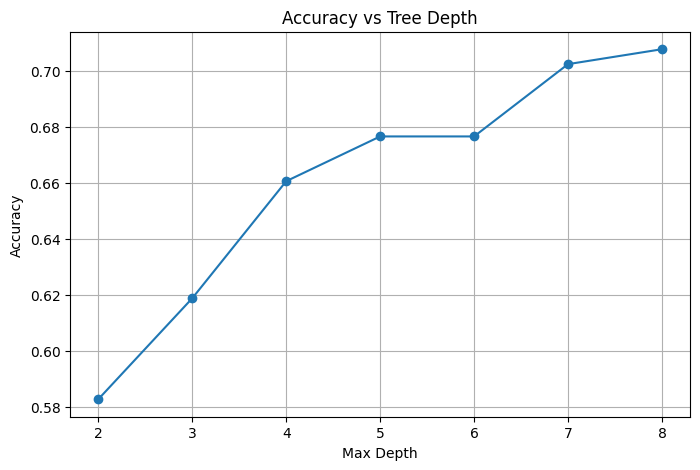

In [9]:
depths = [2, 3, 4, 5, 6, 7, 8]

accuracies = []
rule_counts = []

for depth in depths:
    model = DecisionTreeClassifier(
        max_depth=depth,
        min_samples_leaf=20,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    accuracies.append(acc)
    rule_counts.append(model.get_n_leaves())

# Accuracy Plot
plt.figure(figsize=(8,5))
plt.plot(depths, accuracies, marker='o')

plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Tree Depth")

plt.grid(True)
plt.show()

Wraz ze wzrostem maksymalnej głębokości drzewa decyzyjnego rosła skuteczność klasyfikacji modelu.
Największy wzrost accuracy zaobserwowano dla głębokości od 2 do 4.

Dalsze zwiększanie głębokości drzewa prowadziło już do znacznie mniejszych przyrostów skuteczności, przy jednoczesnym zwiększeniu liczby wygenerowanych reguł IF-THEN oraz spadku interpretowalności modelu.

Z tego względu wybrano kompromis pomiędzy skutecznością klasyfikacji a czytelnością reguł eksperckich.

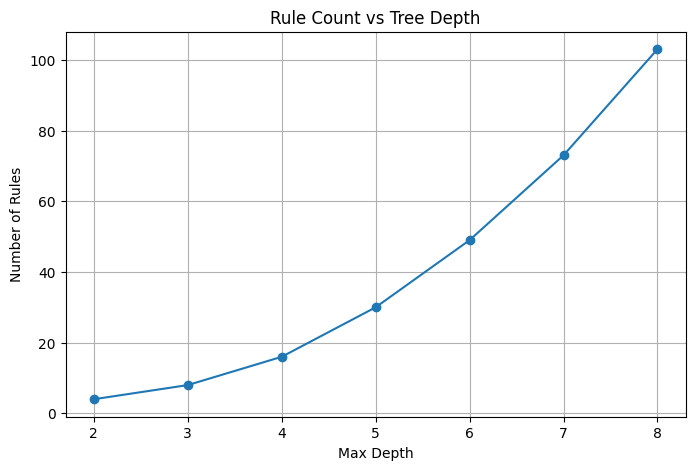

In [10]:
plt.figure(figsize=(8,5))
plt.plot(depths, rule_counts, marker='o')

plt.xlabel("Max Depth")
plt.ylabel("Number of Rules")
plt.title("Rule Count vs Tree Depth")

plt.grid(True)
plt.show()

## Krok 8: Wizualizacja drzewa decyzyjnego

Wizualizujemy strukturę wytrenowanego drzewa decyzyjnego, aby sprawdzić, które cechy są wykorzystywane do klasyfikacji filmów jako successful lub unsuccessful.

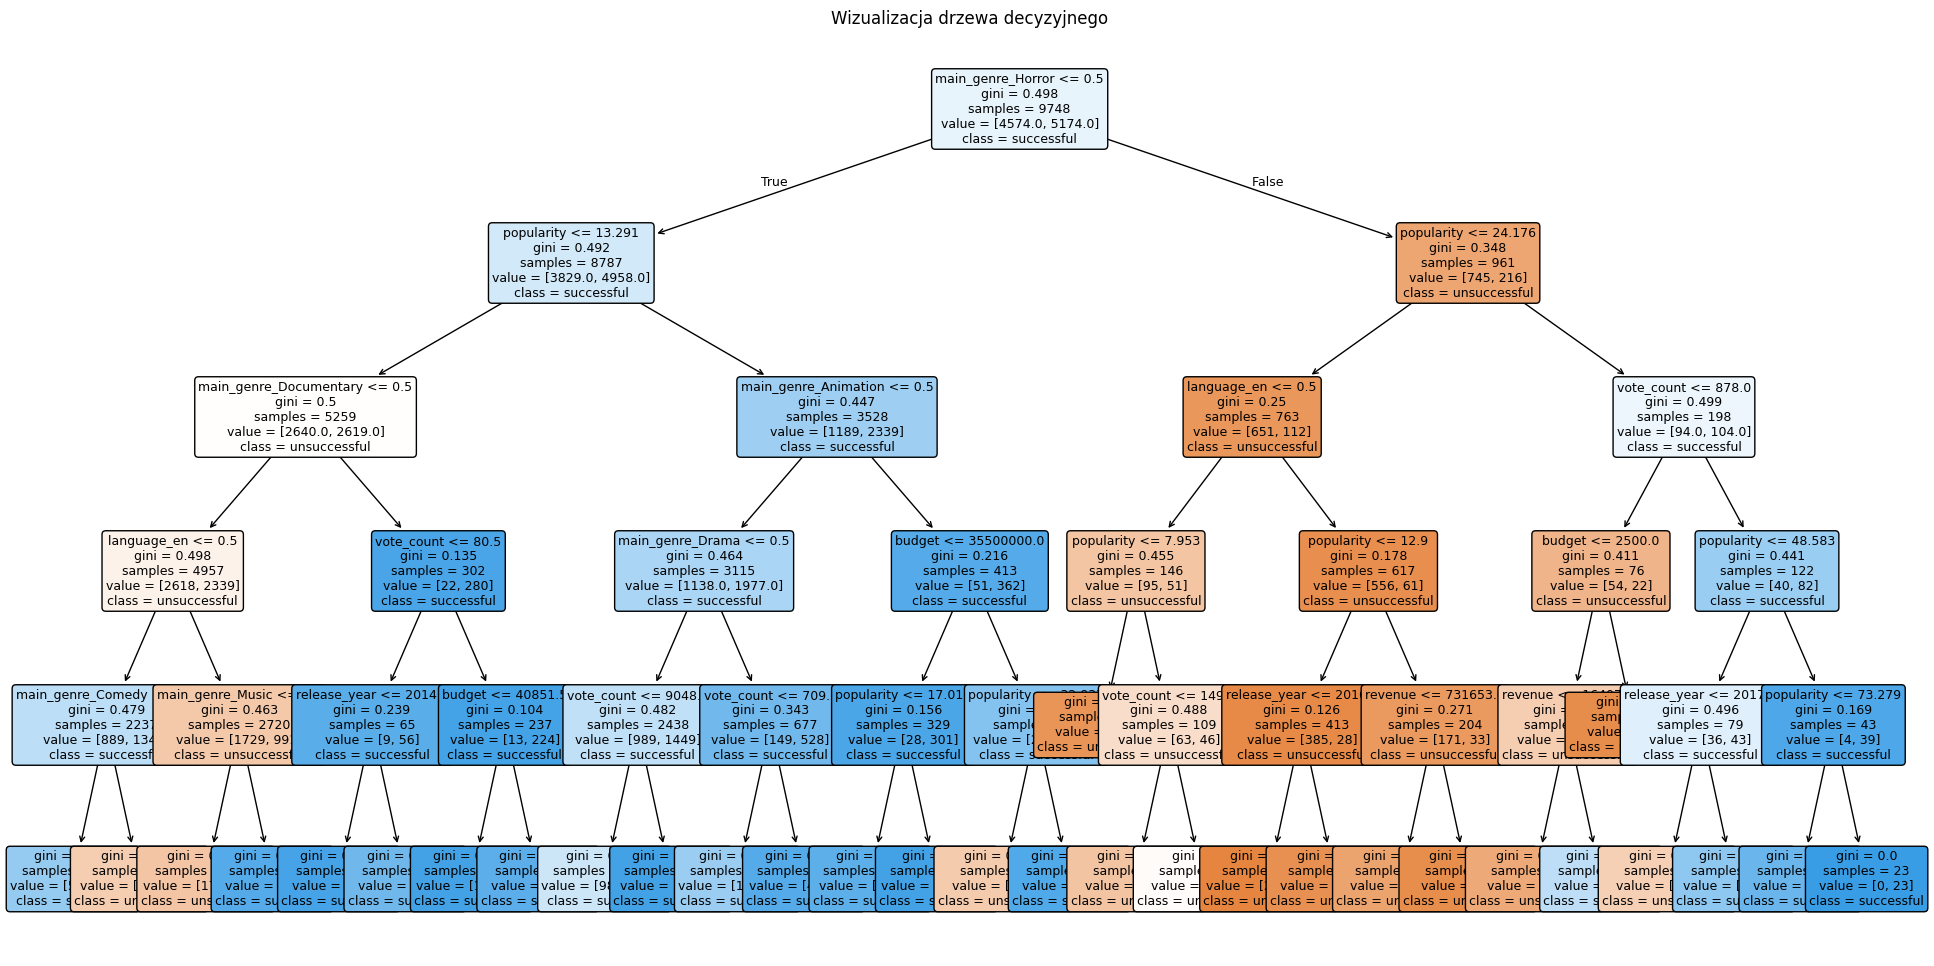

In [11]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(24, 12))

plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=["unsuccessful", "successful"],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Wizualizacja drzewa decyzyjnego")
plt.show()

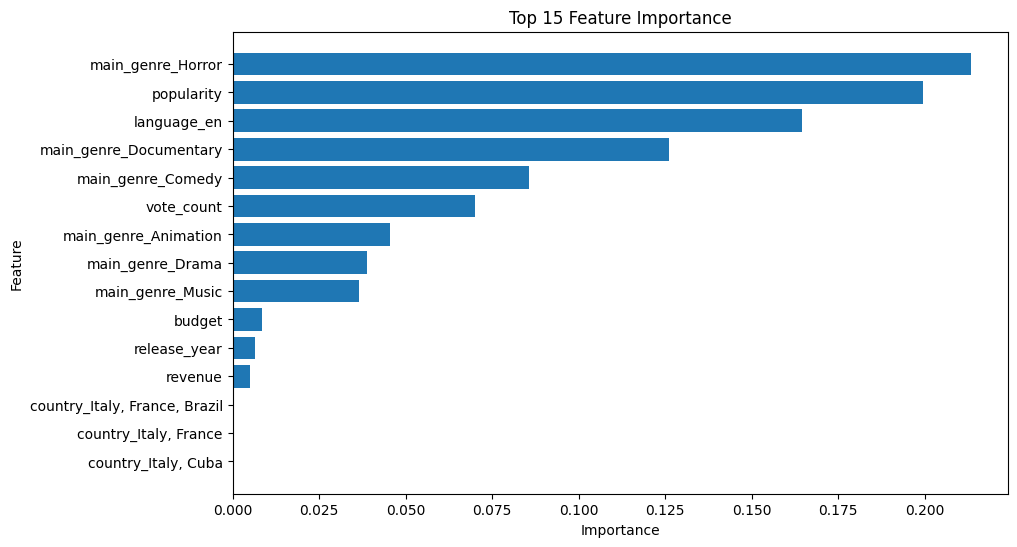

In [12]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': tree_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='importance',
    ascending=False
)

# Беремо тільки топ-15
top_features = feature_importance.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top_features['feature'],
    top_features['importance']
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importance")

plt.gca().invert_yaxis()

plt.show()

Ze względu na wysoką kardynalność cechy country, w analizie feature importance uwzględniono jedynie najbardziej istotne cechy modelu.

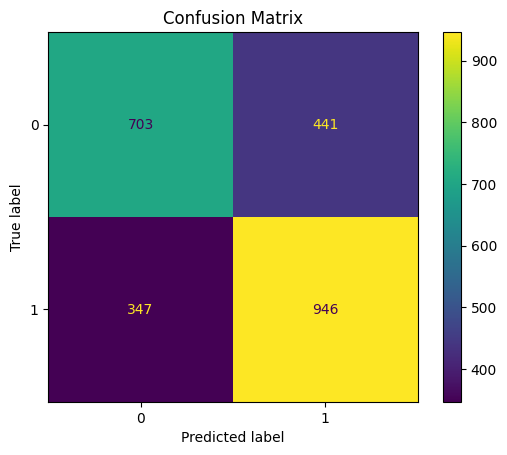

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    tree_model,
    X_test,
    y_test
)

plt.title("Confusion Matrix")
plt.show()

Macierz błędów (Confusion Matrix) przedstawia skuteczność klasyfikacji modelu Decision Tree na zbiorze testowym.

Model poprawnie sklasyfikował 703 przypadki klasy unsuccessful oraz 946 przypadków klasy successful. Jednocześnie wystąpiło 441 przypadków błędnej klasyfikacji filmów `unsuccessful` jako `successful` oraz 347 przypadków błędnej klasyfikacji filmów `successful` jako `unsuccessful`.

Wyniki wskazują, że model osiąga lepszą skuteczność dla klasy `successful`, co jest zgodne z wcześniejszymi wynikami precision oraz recall. Macierz błędów potwierdza również, że model zachowuje względną równowagę pomiędzy obiema klasami i nie wykazuje skrajnego biasu w kierunku jednej kategorii.

## Krok 9: Ekstrakcja reguł IF-THEN

Na tym etapie wyodrębniamy reguły decyzyjne z wytrenowanego drzewa. Reguły te stanowią symboliczną reprezentację wiedzy i mogą zostać wykorzystane
w systemie ekspertowym.

In [14]:
from sklearn.tree import export_text

tree_rules = export_text(
    tree_model,
    feature_names=list(X.columns),
    decimals=3,
    show_weights=True
)

print(tree_rules)

|--- main_genre_Horror <= 0.500
|   |--- popularity <= 13.291
|   |   |--- main_genre_Documentary <= 0.500
|   |   |   |--- language_en <= 0.500
|   |   |   |   |--- main_genre_Comedy <= 0.500
|   |   |   |   |   |--- weights: [523.000, 1125.000] class: 1
|   |   |   |   |--- main_genre_Comedy >  0.500
|   |   |   |   |   |--- weights: [366.000, 223.000] class: 0
|   |   |   |--- language_en >  0.500
|   |   |   |   |--- main_genre_Music <= 0.500
|   |   |   |   |   |--- weights: [1721.000, 935.000] class: 0
|   |   |   |   |--- main_genre_Music >  0.500
|   |   |   |   |   |--- weights: [8.000, 56.000] class: 1
|   |   |--- main_genre_Documentary >  0.500
|   |   |   |--- vote_count <= 80.500
|   |   |   |   |--- release_year <= 2014.500
|   |   |   |   |   |--- weights: [2.000, 31.000] class: 1
|   |   |   |   |--- release_year >  2014.500
|   |   |   |   |   |--- weights: [7.000, 25.000] class: 1
|   |   |   |--- vote_count >  80.500
|   |   |   |   |--- budget <= 40851.500
|   |   

In [15]:
from sklearn.tree import _tree

def extract_rules(tree, feature_names):
    tree_ = tree.tree_
    feature_name = [
        feature_names[i] if i != _tree.TREE_UNDEFINED else "undefined!"
        for i in tree_.feature
    ]

    rules = []

    def recurse(node, path):
        if tree_.feature[node] != _tree.TREE_UNDEFINED:
            name = feature_name[node]
            threshold = tree_.threshold[node]

            left_path = path + [f"({name} <= {threshold:.3f})"]
            recurse(tree_.children_left[node], left_path)

            right_path = path + [f"({name} > {threshold:.3f})"]
            recurse(tree_.children_right[node], right_path)

        else:
            values = tree_.value[node][0]
            predicted_class = tree.classes_[values.argmax()]

            rule = " IF " + " AND ".join(path)
            rule += f" THEN class = {predicted_class}"

            rules.append(rule)

    recurse(0, [])

    return rules

rules = extract_rules(tree_model, list(X.columns))

for i, rule in enumerate(rules, 1):
    print(f"Rule {i}:")
    print(rule)
    print()

Rule 1:
 IF (main_genre_Horror <= 0.500) AND (popularity <= 13.291) AND (main_genre_Documentary <= 0.500) AND (language_en <= 0.500) AND (main_genre_Comedy <= 0.500) THEN class = 1

Rule 2:
 IF (main_genre_Horror <= 0.500) AND (popularity <= 13.291) AND (main_genre_Documentary <= 0.500) AND (language_en <= 0.500) AND (main_genre_Comedy > 0.500) THEN class = 0

Rule 3:
 IF (main_genre_Horror <= 0.500) AND (popularity <= 13.291) AND (main_genre_Documentary <= 0.500) AND (language_en > 0.500) AND (main_genre_Music <= 0.500) THEN class = 0

Rule 4:
 IF (main_genre_Horror <= 0.500) AND (popularity <= 13.291) AND (main_genre_Documentary <= 0.500) AND (language_en > 0.500) AND (main_genre_Music > 0.500) THEN class = 1

Rule 5:
 IF (main_genre_Horror <= 0.500) AND (popularity <= 13.291) AND (main_genre_Documentary > 0.500) AND (vote_count <= 80.500) AND (release_year <= 2014.500) THEN class = 1

Rule 6:
 IF (main_genre_Horror <= 0.500) AND (popularity <= 13.291) AND (main_genre_Documentary > 0

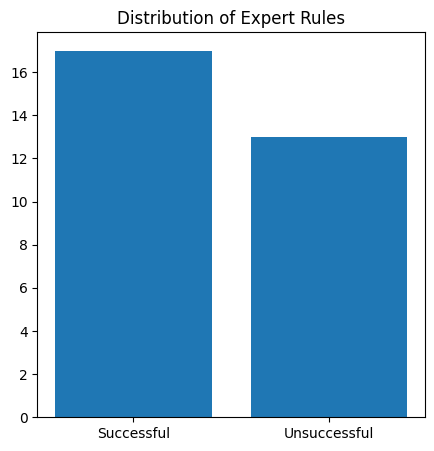

In [16]:
successful_rules = sum("class = 1" in r for r in rules)
unsuccessful_rules = sum("class = 0" in r for r in rules)

plt.figure(figsize=(5,5))

plt.bar(
    ['Successful', 'Unsuccessful'],
    [successful_rules, unsuccessful_rules]
)

plt.title("Distribution of Expert Rules")

plt.show()

Analiza wygenerowanych reguł IF-THEN pokazuje, że najważniejszym czynnikiem wpływającym na klasyfikację filmu okazała się popularność `(popularity)`. Cecha ta pojawia się w większości reguł decyzyjnych, co sugeruje jej silny wpływ na przewidywany sukces filmu.

Zaobserwowano również wyraźną zależność pomiędzy gatunkiem `Horror` a klasą `unsuccessful`. Większość filmów horrorowych była klasyfikowana jako nieudane, szczególnie w przypadku niskiej popularności oraz niewielkiej liczby głosów użytkowników.

Z kolei filmy dokumentalne `(Documentary)` oraz animowane `(Animation)` częściej były klasyfikowane jako `successful`, nawet przy umiarkowanym budżecie produkcji. W przypadku filmów animowanych zauważono jednak, że bardzo wysoki budżet bez odpowiednio wysokiej popularności może prowadzić do klasy `unsuccessful`.

Istotnym czynnikiem wspomagającym klasyfikację okazała się także liczba ocen użytkowników `(vote_count)`, która pełni rolę dodatkowego wskaźnika wiarygodności sukcesu filmu.

W niektórych regułach pojawiały się również cechy takie jak `release_year`, `revenue` oraz `language`, jednak ich wpływ był wyraźnie mniejszy niż wpływ `popularity` oraz głównego gatunku filmu.

Uzyskane reguły mają interpretowalny charakter i mogą zostać wykorzystane jako symboliczna baza wiedzy w systemie ekspertowym.

## Krok 11: Analiza jakości reguł IF-THEN

W tym kroku analizujemy jakość wygenerowanych reguł IF-THEN.
Dla każdej reguły obliczamy support, confidence oraz przewidywaną klasę.
Pozwala to ocenić, które reguły są najbardziej wiarygodne i mogą zostać wykorzystane jako element bazy wiedzy systemu ekspertowego.

In [17]:
import pandas as pd
import numpy as np
from sklearn.tree import _tree

def extract_rules_real_metrics(tree_model, X, y):

    tree_ = tree_model.tree_
    feature_names = list(X.columns)

    rules = []

    def recurse(node, conditions):

        if tree_.feature[node] != _tree.TREE_UNDEFINED:

            feature = feature_names[tree_.feature[node]]
            threshold = tree_.threshold[node]

            recurse(
                tree_.children_left[node],
                conditions + [(feature, "<=", threshold)]
            )

            recurse(
                tree_.children_right[node],
                conditions + [(feature, ">", threshold)]
            )

        else:

            values = tree_.value[node][0]
            predicted_class = int(np.argmax(values))

            rules.append({
                "conditions": conditions,
                "predicted_class": predicted_class
            })

    recurse(0, [])

    rules_data = []

    # REAL METRICS
    for rule in rules:

        mask = pd.Series([True] * len(X), index=X.index)

        for feature, operator, threshold in rule["conditions"]:

            if operator == "<=":
                mask &= X[feature] <= threshold
            else:
                mask &= X[feature] > threshold

        matched_X = X[mask]
        matched_y = y[mask]

        support = len(matched_y)

        if support > 0:
            correct = np.sum(
                matched_y == rule["predicted_class"]
            )

            confidence = correct / support
        else:
            confidence = 0

        rule_text = "IF " + " AND ".join(
            [
                f"{f} {op} {thr:.3f}"
                for f, op, thr in rule["conditions"]
            ]
        )

        rule_text += f" THEN class = {rule['predicted_class']}"

        rules_data.append({
            "rule": rule_text,
            "predicted_class": rule["predicted_class"],
            "support": support,
            "confidence": round(confidence, 3),
            "conditions_count": len(rule["conditions"])
        })

    return pd.DataFrame(rules_data)

rules_df = extract_rules_real_metrics(
    tree_model,
    X_train,
    y_train
)

rules_df = rules_df.sort_values(
    by=["confidence", "support"],
    ascending=False
)

display(rules_df.head(10))

,rule,predicted_class,support,confidence,conditions_count
29,IF main_genre_Horror > 0.500 AND popularity > ...,1,23,1.000,5
19,IF main_genre_Horror > 0.500 AND popularity <=...,0,220,0.968,5
6,IF main_genre_Horror <= 0.500 AND popularity <...,1,217,0.954,5
9,IF main_genre_Horror <= 0.500 AND popularity >...,1,130,0.954,5
13,IF main_genre_Horror <= 0.500 AND popularity >...,1,212,0.953,5
4,IF main_genre_Horror <= 0.500 AND popularity <...,1,33,0.939,5
25,IF main_genre_Horror > 0.500 AND popularity > ...,0,23,0.913,4
22,IF main_genre_Horror > 0.500 AND popularity <=...,0,88,0.909,5
15,IF main_genre_Horror <= 0.500 AND popularity >...,1,57,0.895,5
20,IF main_genre_Horror > 0.500 AND popularity <=...,0,193,0.891,5


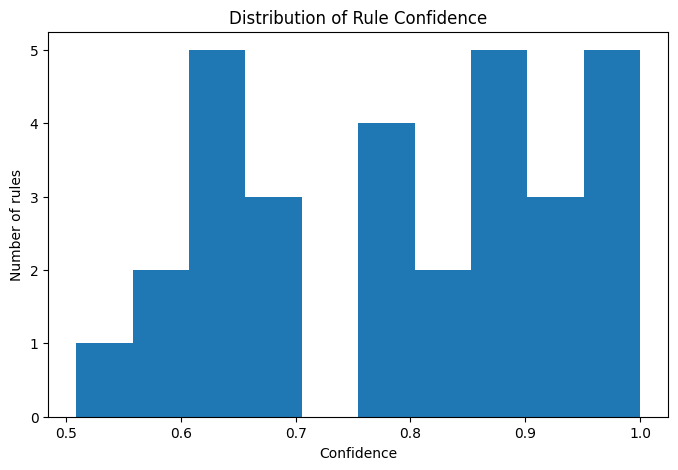

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(rules_df["confidence"], bins=10)

plt.xlabel("Confidence")
plt.ylabel("Number of rules")
plt.title("Distribution of Rule Confidence")

plt.show()

Niektóre reguły osiągały bardzo wysoką wartość confidence (nawet 1.0), jednak obejmowały niewielką liczbę przykładów treningowych.
Oznacza to, że reguły te są bardzo precyzyjne, ale mają ograniczoną ogólność.

Z kolei reguły o większym support charakteryzowały się nieco niższą wartością confidence, jednak obejmowały znacznie większą część zbioru danych.

## Krok 12: Interpretacja i uproszczenie reguł za pomocą LLM

W tym kroku wykorzystujemy model językowy LLM do przekształcenia technicznych reguł IF-THEN w bardziej zrozumiałą postać ekspercką.
Model LLM grupuje podobne reguły, upraszcza ich zapis, wskazuje najważniejsze zależności oraz identyfikuje potencjalne konflikty lub wyjątki w bazie wiedzy.

### Przygotowanie tekstu dla LLM

In [19]:
top_rules_for_llm = rules_df.head(15)

rules_text_for_llm = "\n\n".join(
    [
        f"Rule {i+1}:\n"
        f"{row['rule']}\n"
        f"Predicted class: {'successful' if row['predicted_class'] == 1 else 'unsuccessful'}\n"
        f"Support: {row['support']}\n"
        f"Confidence: {row['confidence']}"
        for i, row in top_rules_for_llm.iterrows()
    ]
)

print(rules_text_for_llm)

Rule 30:
IF main_genre_Horror > 0.500 AND popularity > 24.176 AND vote_count > 878.000 AND popularity > 48.583 AND popularity > 73.279 THEN class = 1
Predicted class: successful
Support: 23
Confidence: 1.0

Rule 20:
IF main_genre_Horror > 0.500 AND popularity <= 24.176 AND language_en > 0.500 AND popularity <= 12.900 AND release_year <= 2016.500 THEN class = 0
Predicted class: unsuccessful
Support: 220
Confidence: 0.968

Rule 7:
IF main_genre_Horror <= 0.500 AND popularity <= 13.291 AND main_genre_Documentary > 0.500 AND vote_count > 80.500 AND budget <= 40851.500 THEN class = 1
Predicted class: successful
Support: 217
Confidence: 0.954

Rule 10:
IF main_genre_Horror <= 0.500 AND popularity > 13.291 AND main_genre_Animation <= 0.500 AND main_genre_Drama <= 0.500 AND vote_count > 9048.500 THEN class = 1
Predicted class: successful
Support: 130
Confidence: 0.954

Rule 14:
IF main_genre_Horror <= 0.500 AND popularity > 13.291 AND main_genre_Animation > 0.500 AND budget <= 35500000.000 AND

In [20]:
llm_prompt = f"""
You are helping to build an expert system for classifying Netflix movies as successful or unsuccessful.

Class meaning:
- class = 1 means successful
- class = 0 means unsuccessful

The following rules were extracted from a Decision Tree model.
Each rule contains:
- technical IF-THEN conditions,
- predicted class,
- support,
- confidence.

Your tasks:
1. Rewrite each rule into a clear human-readable expert rule.
2. Group similar rules into broader knowledge patterns.
3. Remove or mention redundant rules.
4. Identify possible conflicts or exceptions.
5. Explain what the system considers a movie success factor.
6. Return the result in Polish.

Rules:
{rules_text_for_llm}
"""

print(llm_prompt[:3000])


You are helping to build an expert system for classifying Netflix movies as successful or unsuccessful.

Class meaning:
- class = 1 means successful
- class = 0 means unsuccessful

The following rules were extracted from a Decision Tree model.
Each rule contains:
- technical IF-THEN conditions,
- predicted class,
- support,
- confidence.

Your tasks:
1. Rewrite each rule into a clear human-readable expert rule.
2. Group similar rules into broader knowledge patterns.
3. Remove or mention redundant rules.
4. Identify possible conflicts or exceptions.
5. Explain what the system considers a movie success factor.
6. Return the result in Polish.

Rules:
Rule 30:
IF main_genre_Horror > 0.500 AND popularity > 24.176 AND vote_count > 878.000 AND popularity > 48.583 AND popularity > 73.279 THEN class = 1
Predicted class: successful
Support: 23
Confidence: 1.0

Rule 20:
IF main_genre_Horror > 0.500 AND popularity <= 24.176 AND language_en > 0.500 AND popularity <= 12.900 AND release_year <= 2016

In [22]:
import os
import getpass
from google import genai

if not os.getenv("GEMINI_API_KEY"):
    os.environ["GEMINI_API_KEY"] = getpass.getpass("GEMINI_API_KEY: ")

client = genai.Client()

response = client.models.generate_content(
    model="gemini-3.5-flash",
    contents=(
        "You are an expert in machine learning, rule-based expert systems "
        "and explainable AI. Use only the supplied rules. Return the result in Polish.\n\n"
        + llm_prompt
    )
)

llm_analysis = response.text
print(llm_analysis)

GEMINI_API_KEY: ··········
Jako ekspert w dziedzinie uczenia maszynowego, systemów ekspertowych i wyjaśnialnej sztucznej inteligencji (XAI), poniżej przedstawiam szczegółową analizę i przetworzenie reguł decyzyjnych dla systemu klasyfikacji filmów Netflix.

---

### 1. Sformułowanie reguł w języku naturalnym (Expert Rules)

Poniżej znajduje się uproszczona i zrozumiała dla człowieka interpretacja każdej z reguł, z usunięciem matematycznych redundancji (np. wielokrotnych progów dla tej samej zmiennej).

*   **Reguła 30 (Sukces):** JEŚLI film to **Horror** ORAZ jest wyjątkowo **popularny (popularność > 73.279)** ORAZ ma **dużo ocen (liczba głosów > 878)**, TO odniesie sukces.
    *   *Wsparcie: 23 | Pewność: 100%*
*   **Reguła 20 (Porażka):** JEŚLI film to **Horror** w języku **angielskim** wydany **w 2016 roku lub wcześniej** ORAZ ma bardzo **niską popularność (<= 12.9)**, TO nie odniesie sukcesu.
    *   *Wsparcie: 220 | Pewność: 96.8%*
*   **Reguła 7 (Sukces):** JEŚLI film to **Dokume

### Wniosek końcowy

Wygenerowana przez LLM interpretacja pokazuje, że system ekspertowy oparty na drzewie decyzyjnym identyfikuje kilka głównych czynników związanych z klasyfikacją filmu jako successful: popularność, liczbę głosów, główny gatunek, język, budżet oraz rok wydania.

Należy jednak podkreślić, że w tym projekcie pojęcie sukcesu nie oznacza bezpośrednio sukcesu finansowego ani biznesowego platformy Netflix. Zmienna docelowa `is_success` została zdefiniowana na podstawie wartości `vote_average`, dlatego film successful oznacza film oceniony co najmniej na poziomie mediany ocen w zbiorze danych.

LLM nie zastępuje modelu klasyfikacyjnego. Jego rolą jest interpretacja, uproszczenie i uporządkowanie reguł IF-THEN wygenerowanych przez Decision Tree. Dzięki temu techniczne reguły modelu ML zostają przekształcone w bardziej zrozumiałą bazę wiedzy systemu ekspertowego.

# Krok 13: Demonstracja systemu ekspertowego
W ostatnim kroku tworzymy prostą demonstrację działania systemu ekspertowego. Użytkownik podaje parametry filmu, a system zwraca przewidywaną klasę (`successful` / `unsuccessful`) oraz wyjaśnienie decyzji w postaci ścieżki reguł wykorzystanej przez drzewo decyzyjne.

In [23]:
def prepare_movie_for_prediction(movie_data, training_columns):
    """Convert one movie description to the same feature space as the training data."""
    movie_encoded = pd.DataFrame(0, index=[0], columns=training_columns)

    numeric_features = ['release_year', 'popularity', 'vote_count', 'budget', 'revenue']
    for feature in numeric_features:
        if feature in movie_encoded.columns:
            movie_encoded.loc[0, feature] = movie_data.get(feature, 0)

    categorical_features = ['country', 'language', 'main_genre']
    for feature in categorical_features:
        value = movie_data.get(feature)
        dummy_column = f"{feature}_{value}"
        if dummy_column in movie_encoded.columns:
            movie_encoded.loc[0, dummy_column] = 1

    return movie_encoded


def describe_tree_condition(feature_name, operator, threshold):
    """Translate a technical tree split into a readable expert-system condition."""
    if feature_name.startswith('main_genre_'):
        genre = feature_name.replace('main_genre_', '')
        return f"gatunek {'jest' if operator == '>' else 'nie jest'} {genre}"

    if feature_name.startswith('language_'):
        language = feature_name.replace('language_', '')
        return f"język {'jest' if operator == '>' else 'nie jest'} {language}"

    if feature_name.startswith('country_'):
        country = feature_name.replace('country_', '')
        return f"kraj produkcji {'zawiera' if operator == '>' else 'nie zawiera'} {country}"

    return f"{feature_name} {operator} {threshold:.3f}"


def get_decision_path_explanation(model, encoded_movie, feature_names):
    """Return the IF-THEN path used by the Decision Tree for one prediction."""
    tree = model.tree_
    node_indicator = model.decision_path(encoded_movie)
    leaf_id = model.apply(encoded_movie)[0]

    conditions = []
    node_index = node_indicator.indices[
        node_indicator.indptr[0]:node_indicator.indptr[1]
    ]

    for node_id in node_index:
        if node_id == leaf_id:
            continue

        feature_id = tree.feature[node_id]
        feature_name = feature_names[feature_id]
        threshold = tree.threshold[node_id]
        value = encoded_movie.iloc[0, feature_id]
        operator = '<=' if value <= threshold else '>'

        conditions.append(
            describe_tree_condition(feature_name, operator, threshold)
        )

    return conditions


def predict_movie_with_explanation(movie_data):
    """Predict movie success and explain the exact expert rule path."""
    encoded_movie = prepare_movie_for_prediction(movie_data, X.columns)

    prediction = int(tree_model.predict(encoded_movie)[0])
    label = 'successful' if prediction == 1 else 'unsuccessful'

    probability = None
    if hasattr(tree_model, 'predict_proba'):
        probability = tree_model.predict_proba(encoded_movie)[0][prediction]

    conditions = get_decision_path_explanation(
        tree_model,
        encoded_movie,
        list(X.columns)
    )

    print('Dane wejściowe filmu:')
    for key, value in movie_data.items():
        print(f'- {key}: {value}')

    print(f"\nPredykcja systemu ekspertowego: {label}")
    if probability is not None:
        print(f"Pewność modelu dla tej klasy: {probability:.3f}")

    print('\nWyjaśnienie decyzji - zastosowana ścieżka reguł:')
    for i, condition in enumerate(conditions, 1):
        print(f'{i}. {condition}')

    return {
        'prediction': prediction,
        'label': label,
        'probability': probability,
        'conditions': conditions
    }


#Przykładowe użycie demonstracji
Poniżej można zmienić parametry przykładowego filmu i ponownie uruchomić komórkę, aby sprawdzić decyzję systemu ekspertowego.



In [24]:
example_movie = {
    'country': 'United States of America',
    'release_year': 2024,
    'language': 'en',
    'popularity': 80.0,
    'vote_count': 1500,
    'budget': 12000000,
    'revenue': 60000000,
    'main_genre': 'Horror'
}

expert_demo_result = predict_movie_with_explanation(example_movie)


Dane wejściowe filmu:
- country: United States of America
- release_year: 2024
- language: en
- popularity: 80.0
- vote_count: 1500
- budget: 12000000
- revenue: 60000000
- main_genre: Horror

Predykcja systemu ekspertowego: successful
Pewność modelu dla tej klasy: 1.000

Wyjaśnienie decyzji - zastosowana ścieżka reguł:
1. gatunek jest Horror
2. popularity > 24.176
3. vote_count > 878.000
4. popularity > 48.583
5. popularity > 73.279
